In [1]:
import os
import sys
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
from daaq.utils.plot_tools import setupax_2dmap
from daaq.obs_utils.ioda_tools import IODAFile

In [ ]:
# Setup the IODA file and figure output folder
obspath = "/glade/campaign/ncar/nmmm0072/Data/obs_pandac"
obstype = "oci_uaa_pace_aod"
cdate = "2024110100"
iodafile = f"{obspath}/{obstype}/{cdate}/{obstype}_obs_{cdate}.h5"

figsavedir = '/glade/derecho/scratch/swei/data_process_tmp'
savefig = False
quality = 600
figname_tmpl = '{group}.{obstype}.png'

area_corner = None
proj = ccrs.PlateCarree()

In [3]:
# Process single IODA file
ioda_obj = IODAFile(iodafile)
ioda_obj.channel_meta

{'sensorCentralFrequency': masked_array(data=[8.4687138e+14, 7.7266099e+14, 6.2456763e+14,
                    5.4507719e+14, 4.4745144e+14, 3.4458902e+14,
                    2.4176810e+14, 1.8280028e+14, 1.3626930e+14],
              mask=False,
        fill_value=1e+20,
             dtype=float32),
 'sensorCentralWavelength': masked_array(data=[0.354, 0.388, 0.48 , 0.55 , 0.67 , 0.87 , 1.24 , 1.64 ,
                    2.2  ],
              mask=False,
        fill_value=1e+20,
             dtype=float32)}

In [4]:
# Load ioda file into dataframe
ioda_df = ioda_obj.load()
ioda_df

,dateTime,latitude,longitude,surfaceQualifier,ObsError_aerosolOpticalDepth_0,ObsError_aerosolOpticalDepth_1,ObsError_aerosolOpticalDepth_2,ObsError_aerosolOpticalDepth_3,ObsError_aerosolOpticalDepth_4,ObsError_aerosolOpticalDepth_5,...,ObsValue_aerosolOpticalDepth_8,PreQC_aerosolOpticalDepth_0,PreQC_aerosolOpticalDepth_1,PreQC_aerosolOpticalDepth_2,PreQC_aerosolOpticalDepth_3,PreQC_aerosolOpticalDepth_4,PreQC_aerosolOpticalDepth_5,PreQC_aerosolOpticalDepth_6,PreQC_aerosolOpticalDepth_7,PreQC_aerosolOpticalDepth_8
0,2024-10-31 21:58:02+00:00,-74.445419,-105.937378,0,0.08105,0.07580,0.06560,0.06125,0.05675,0.05330,...,0.002,2,2,2,2,2,2,2,2,2
1,2024-10-31 21:58:02+00:00,-74.408272,-105.701462,0,0.08060,0.07550,0.06530,0.06110,0.05660,0.05330,...,0.002,2,2,2,2,2,2,2,2,2
2,2024-10-31 21:58:02+00:00,-74.454376,-106.554688,0,0.08555,0.07985,0.06830,0.06350,0.05840,0.05465,...,0.009,2,2,2,2,2,2,2,2,2
3,2024-10-31 21:58:02+00:00,-74.417686,-106.316528,0,0.08210,0.07685,0.06650,0.06215,0.05765,0.05420,...,0.009,2,2,2,2,2,2,2,2,2
4,2024-10-31 21:58:02+00:00,-74.380814,-106.079865,0,0.07700,0.07265,0.06425,0.06065,0.05690,0.05420,...,0.012,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181954,2024-11-01 02:57:54+00:00,-48.197987,165.705719,0,0.07955,0.07505,0.06440,0.06245,0.05990,0.05735,...,0.021,0,0,0,0,0,0,0,0,0
181955,2024-11-01 02:57:54+00:00,-47.936069,166.872162,0,0.07385,0.07040,0.06200,0.06065,0.05885,0.05705,...,0.024,0,0,0,0,0,0,0,0,0
181956,2024-11-01 02:57:54+00:00,-47.717972,167.812714,0,0.07205,0.07040,0.06620,0.06425,0.06185,0.05930,...,0.027,0,0,0,0,0,0,0,0,0
181957,2024-11-01 02:57:54+00:00,-47.670467,168.014114,0,0.07850,0.07475,0.06560,0.06395,0.06185,0.05975,...,0.033,0,0,0,0,0,0,0,0,0


In [5]:
ioda_obj._channel_index

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [6]:
# Select sub channels
subchnls_df = ioda_obj.select_channel([0, 3, 6]).load()
subchnls_df

,dateTime,latitude,longitude,surfaceQualifier,ObsError_aerosolOpticalDepth_0,ObsError_aerosolOpticalDepth_3,ObsError_aerosolOpticalDepth_6,ObsValue_aerosolOpticalDepth_0,ObsValue_aerosolOpticalDepth_3,ObsValue_aerosolOpticalDepth_6,PreQC_aerosolOpticalDepth_0,PreQC_aerosolOpticalDepth_3,PreQC_aerosolOpticalDepth_6
0,2024-10-31 21:58:02+00:00,-74.445419,-105.937378,0,0.08105,0.06125,0.05120,0.207,0.075,0.008,2,2,2
1,2024-10-31 21:58:02+00:00,-74.408272,-105.701462,0,0.08060,0.06110,0.05120,0.204,0.074,0.008,2,2,2
2,2024-10-31 21:58:02+00:00,-74.454376,-106.554688,0,0.08555,0.06350,0.05225,0.237,0.090,0.015,2,2,2
3,2024-10-31 21:58:02+00:00,-74.417686,-106.316528,0,0.08210,0.06215,0.05210,0.214,0.081,0.014,2,2,2
4,2024-10-31 21:58:02+00:00,-74.380814,-106.079865,0,0.07700,0.06065,0.05255,0.180,0.071,0.017,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181954,2024-11-01 02:57:54+00:00,-48.197987,165.705719,0,0.07955,0.06245,0.05510,0.197,0.083,0.034,0,0,0
181955,2024-11-01 02:57:54+00:00,-47.936069,166.872162,0,0.07385,0.06065,0.05540,0.159,0.071,0.036,0,0,0
181956,2024-11-01 02:57:54+00:00,-47.717972,167.812714,0,0.07205,0.06425,0.05675,0.147,0.095,0.045,0,0,0
181957,2024-11-01 02:57:54+00:00,-47.670467,168.014114,0,0.07850,0.06395,0.05765,0.190,0.093,0.051,0,0,0


In [7]:
ioda_obj._channel_index

[0, 3, 6]

In [8]:
ioda_obj.variables('ObsValue')[0]

'aerosolOpticalDepth'

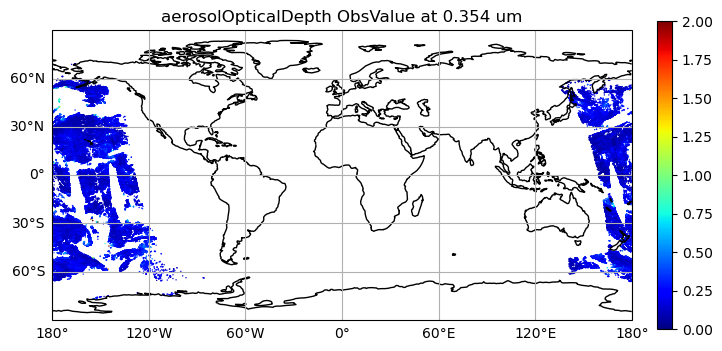

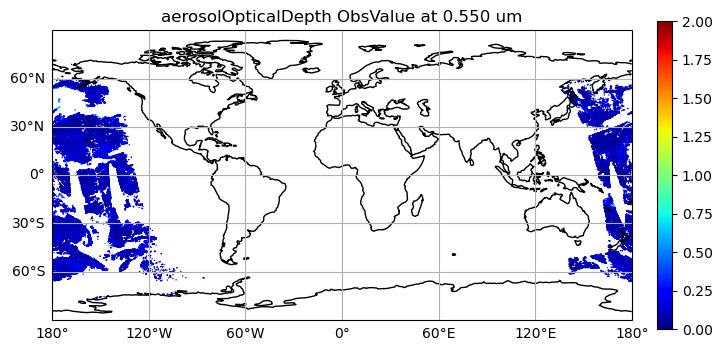

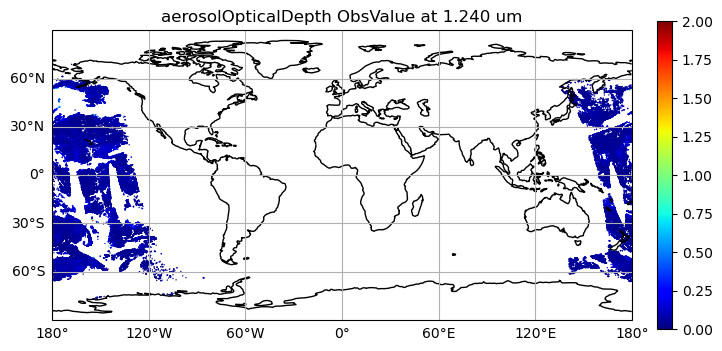

In [9]:
plotgrp = 'ObsValue'
plotvar = 'aerosolOpticalDepth'
for chidx in ioda_obj._channel_index:
    plot_col = f'{plotgrp}_{plotvar}_{chidx}'
    titlestr = f'{plotvar} {plotgrp} at {ioda_obj.channel_meta['sensorCentralWavelength'][chidx]:.3f} um'

    fig, ax, gl = setupax_2dmap(None, gl_lbsize=10)
    sc = plt.scatter(
        subchnls_df['longitude'],
        subchnls_df['latitude'],
        c=subchnls_df[plot_col],
        s=1,
        cmap='jet',
        vmin=0.,
        vmax=2.,
        edgecolors="None",
    )
    ax.set_title(titlestr)
    plt.colorbar(sc, fraction=0.025, pad=0.04, aspect=20)

In [10]:
# Random thinning
ioda_obj.thin('./test-thinned.h5', thinning_ratio=0.8)
thinned = IODAFile('./test-thinned.h5')
thinned_df = thinned.load()
thinned_df

36213 of 181959 observations selected (19.9%).


,dateTime,latitude,longitude,surfaceQualifier,ObsError_aerosolOpticalDepth_0,ObsError_aerosolOpticalDepth_1,ObsError_aerosolOpticalDepth_2,ObsError_aerosolOpticalDepth_3,ObsError_aerosolOpticalDepth_4,ObsError_aerosolOpticalDepth_5,...,ObsValue_aerosolOpticalDepth_8,PreQC_aerosolOpticalDepth_0,PreQC_aerosolOpticalDepth_1,PreQC_aerosolOpticalDepth_2,PreQC_aerosolOpticalDepth_3,PreQC_aerosolOpticalDepth_4,PreQC_aerosolOpticalDepth_5,PreQC_aerosolOpticalDepth_6,PreQC_aerosolOpticalDepth_7,PreQC_aerosolOpticalDepth_8
0,2024-10-31 21:58:02+00:00,-74.417686,-106.316528,0,0.08210,0.07685,0.06650,0.06215,0.05765,0.05420,...,0.009,2,2,2,2,2,2,2,2,2
1,2024-10-31 21:58:02+00:00,-74.306641,-105.610657,0,0.07775,0.07340,0.06470,0.06110,0.05735,0.05465,...,0.014,2,2,2,2,2,2,2,2,2
2,2024-10-31 21:58:02+00:00,-74.140633,-105.663239,0,0.07955,0.07460,0.06485,0.06065,0.05630,0.05300,...,0.001,2,2,2,2,2,2,2,2,2
3,2024-10-31 21:58:02+00:00,-73.557152,-102.295044,0,0.08015,0.07505,0.06500,0.06080,0.05645,0.05300,...,0.001,2,2,2,2,2,2,2,2,2
4,2024-10-31 21:58:02+00:00,-73.472786,-102.812119,0,0.07745,0.07280,0.06365,0.05990,0.05585,0.05270,...,0.001,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36208,2024-11-01 02:57:54+00:00,-49.268688,160.840805,0,0.10220,0.09470,0.07640,0.07310,0.06890,0.06455,...,0.048,0,0,0,0,0,0,0,0,0
36209,2024-11-01 02:57:54+00:00,-49.227558,161.059647,0,0.10040,0.09365,0.07730,0.07430,0.07055,0.06680,...,0.070,0,0,0,0,0,0,0,0,0
36210,2024-11-01 02:57:54+00:00,-49.315998,160.159805,0,0.10820,0.09980,0.07970,0.07610,0.07145,0.06680,...,0.061,0,0,0,0,0,0,0,0,0
36211,2024-11-01 02:57:54+00:00,-48.197987,165.705719,0,0.07955,0.07505,0.06440,0.06245,0.05990,0.05735,...,0.021,0,0,0,0,0,0,0,0,0


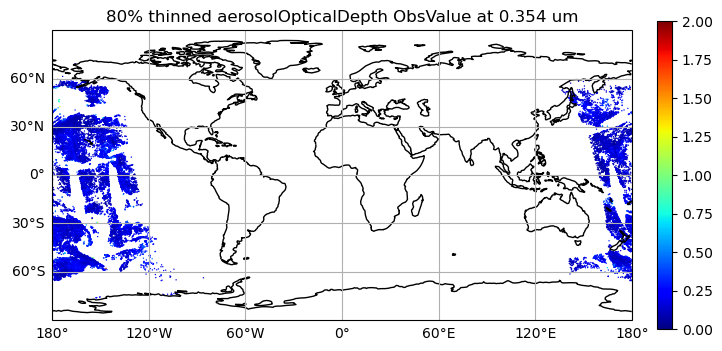

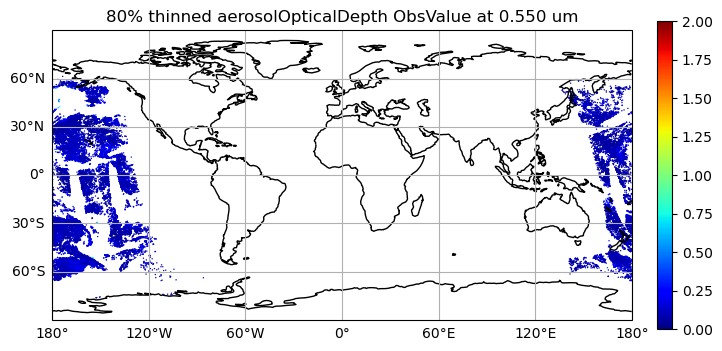

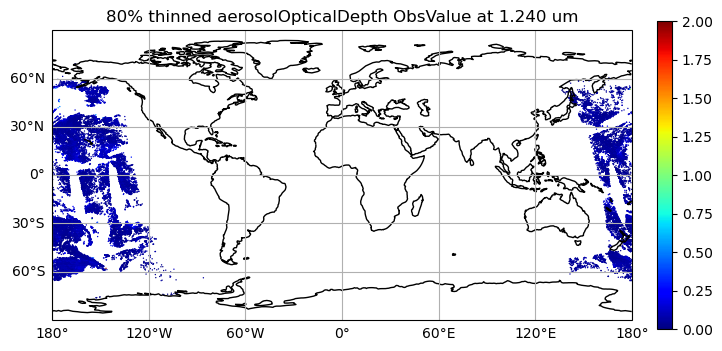

In [11]:
plotgrp = 'ObsValue'
plotvar = 'aerosolOpticalDepth'
plotch_list = [0, 3, 6]
for chidx in plotch_list:
    plot_col = f'{plotgrp}_{plotvar}_{chidx}'
    titlestr = f'80% thinned {plotvar} {plotgrp} at {ioda_obj.channel_meta['sensorCentralWavelength'][chidx]:.3f} um'

    fig, ax, gl = setupax_2dmap(None, gl_lbsize=10)
    sc = plt.scatter(
        thinned_df['longitude'],
        thinned_df['latitude'],
        c=thinned_df[plot_col],
        s=1,
        cmap='jet',
        vmin=0.,
        vmax=2.,
        edgecolors="None",
    )
    ax.set_title(titlestr)
    plt.colorbar(sc, fraction=0.025, pad=0.04, aspect=20)

In [12]:
# Crop IODA file
poly_df = pd.DataFrame({
    'Lat': [0, 40, 40, 0, 0],
    'Lon': [-180, -180, -140, -140, -180],
})
poly_df.to_csv('./croptest_polygon.csv', index=False)
del(poly_df)
poly_df = pd.read_csv('./croptest_polygon.csv')
ioda_obj.crop('./test-cropped.h5', './croptest_polygon.csv')
cropped = IODAFile('./test-cropped.h5')
cropped_df = cropped.load()
cropped_df

44613 of 181959 observations selected (24.5%).


,dateTime,latitude,longitude,surfaceQualifier,ObsError_aerosolOpticalDepth_0,ObsError_aerosolOpticalDepth_1,ObsError_aerosolOpticalDepth_2,ObsError_aerosolOpticalDepth_3,ObsError_aerosolOpticalDepth_4,ObsError_aerosolOpticalDepth_5,...,ObsValue_aerosolOpticalDepth_8,PreQC_aerosolOpticalDepth_0,PreQC_aerosolOpticalDepth_1,PreQC_aerosolOpticalDepth_2,PreQC_aerosolOpticalDepth_3,PreQC_aerosolOpticalDepth_4,PreQC_aerosolOpticalDepth_5,PreQC_aerosolOpticalDepth_6,PreQC_aerosolOpticalDepth_7,PreQC_aerosolOpticalDepth_8
0,2024-10-31 22:18:02+00:00,0.016819,-144.944473,0,0.07745,0.07610,0.07280,0.07115,0.06935,0.06770,...,0.093,0,0,0,0,0,0,0,0,0
1,2024-10-31 22:18:02+00:00,0.004548,-145.472366,0,0.07010,0.06905,0.06650,0.06530,0.06380,0.06245,...,0.061,0,0,0,0,0,0,0,0,0
2,2024-10-31 22:18:02+00:00,0.026745,-145.339752,0,0.07655,0.07355,0.06635,0.06515,0.06365,0.06230,...,0.056,0,0,0,0,0,0,0,0,0
3,2024-10-31 22:18:02+00:00,0.048542,-145.210327,0,0.08165,0.07805,0.06935,0.06800,0.06635,0.06470,...,0.073,0,0,0,0,0,0,0,0,0
4,2024-10-31 22:18:02+00:00,0.069958,-145.083878,0,0.08345,0.08030,0.07295,0.07145,0.06980,0.06845,...,0.105,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44608,2024-11-01 01:34:37+00:00,7.994319,-179.513077,0,0.12680,0.11930,0.10220,0.09875,0.09425,0.08915,...,0.115,2,2,2,2,2,2,2,2,2
44609,2024-11-01 01:34:37+00:00,8.092295,-179.153656,0,0.11525,0.10910,0.09620,0.09245,0.08825,0.08420,...,0.118,2,2,2,2,2,2,2,2,2
44610,2024-11-01 01:34:37+00:00,8.068011,-179.526688,0,0.12665,0.11975,0.10430,0.10115,0.09725,0.09245,...,0.128,2,2,2,2,2,2,2,2,2
44611,2024-11-01 01:34:37+00:00,8.165912,-179.167145,0,0.11330,0.10925,0.10025,0.09875,0.09680,0.09380,...,0.141,2,2,2,2,2,2,2,2,2


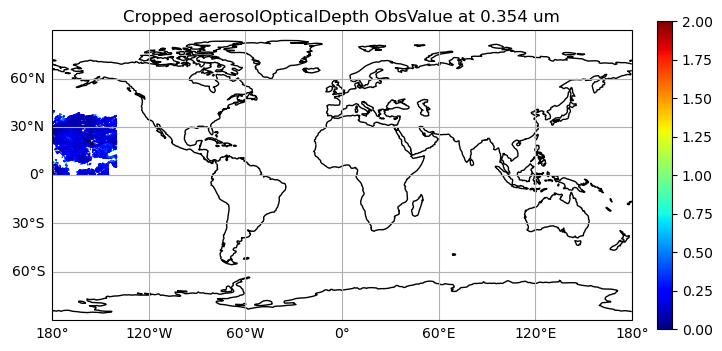

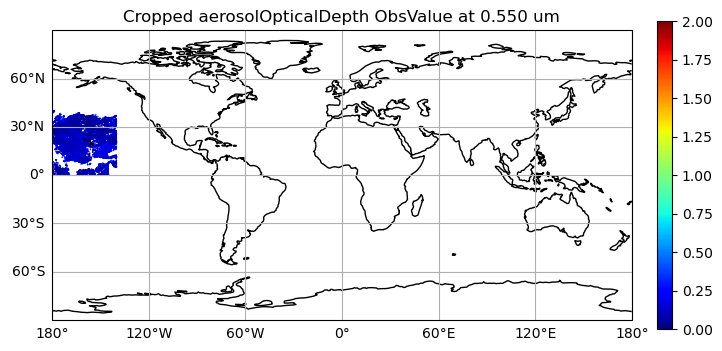

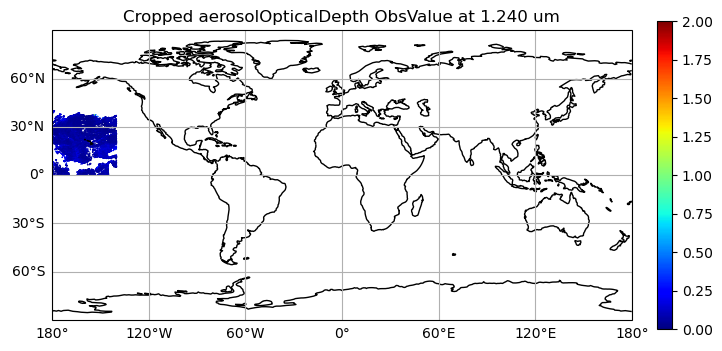

In [13]:
plotgrp = 'ObsValue'
plotvar = 'aerosolOpticalDepth'
plotch_list = [0, 3, 6]
for chidx in plotch_list:
    plot_col = f'{plotgrp}_{plotvar}_{chidx}'
    titlestr = f'Cropped {plotvar} {plotgrp} at {ioda_obj.channel_meta['sensorCentralWavelength'][chidx]:.3f} um'

    fig, ax, gl = setupax_2dmap(None, gl_lbsize=10)
    sc = plt.scatter(
        cropped_df['longitude'],
        cropped_df['latitude'],
        c=cropped_df[plot_col],
        s=1,
        cmap='jet',
        vmin=0.,
        vmax=2.,
        edgecolors="None",
    )
    ax.set_title(titlestr)
    plt.colorbar(sc, fraction=0.025, pad=0.04, aspect=20)

In [14]:
# load multiple IODA files
iodafiles = [
    '/glade/campaign/ncar/nmmm0072/Data/obs_pandac/oci_uaa_pace_aod/2024110100/oci_uaa_pace_aod_obs_2024110100.h5',
    '/glade/campaign/ncar/nmmm0072/Data/obs_pandac/oci_uaa_pace_aod/2024110106/oci_uaa_pace_aod_obs_2024110106.h5',
    '/glade/campaign/ncar/nmmm0072/Data/obs_pandac/oci_uaa_pace_aod/2024110112/oci_uaa_pace_aod_obs_2024110112.h5',
    '/glade/campaign/ncar/nmmm0072/Data/obs_pandac/oci_uaa_pace_aod/2024110118/oci_uaa_pace_aod_obs_2024110118.h5',
]
multi_df, channel_meta = IODAFile.concat(iodafiles, channel_index=[0, 3, 6])
multi_df

,dateTime,latitude,longitude,surfaceQualifier,ObsError_aerosolOpticalDepth_0,ObsError_aerosolOpticalDepth_3,ObsError_aerosolOpticalDepth_6,ObsValue_aerosolOpticalDepth_0,ObsValue_aerosolOpticalDepth_3,ObsValue_aerosolOpticalDepth_6,PreQC_aerosolOpticalDepth_0,PreQC_aerosolOpticalDepth_3,PreQC_aerosolOpticalDepth_6
0,2024-10-31 21:58:02+00:00,-74.445419,-105.937378,0,0.08105,0.06125,0.05120,0.207,0.075,0.008,2,2,2
1,2024-10-31 21:58:02+00:00,-74.408272,-105.701462,0,0.08060,0.06110,0.05120,0.204,0.074,0.008,2,2,2
2,2024-10-31 21:58:02+00:00,-74.454376,-106.554688,0,0.08555,0.06350,0.05225,0.237,0.090,0.015,2,2,2
3,2024-10-31 21:58:02+00:00,-74.417686,-106.316528,0,0.08210,0.06215,0.05210,0.214,0.081,0.014,2,2,2
4,2024-10-31 21:58:02+00:00,-74.380814,-106.079865,0,0.07700,0.06065,0.05255,0.180,0.071,0.017,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887194,2024-11-01 20:59:04+00:00,-47.766258,-101.995125,0,0.09830,0.06965,0.05645,0.322,0.131,0.043,2,2,2
887195,2024-11-01 20:59:04+00:00,-47.663139,-101.564941,0,0.08345,0.07055,0.05720,0.223,0.137,0.048,2,2,2
887196,2024-11-01 20:59:04+00:00,-47.434517,-100.630028,0,0.09260,0.07490,0.06590,0.284,0.166,0.106,2,2,2
887197,2024-11-01 20:59:04+00:00,-47.306828,-100.118675,0,0.12425,0.08090,0.06095,0.495,0.206,0.073,2,2,2


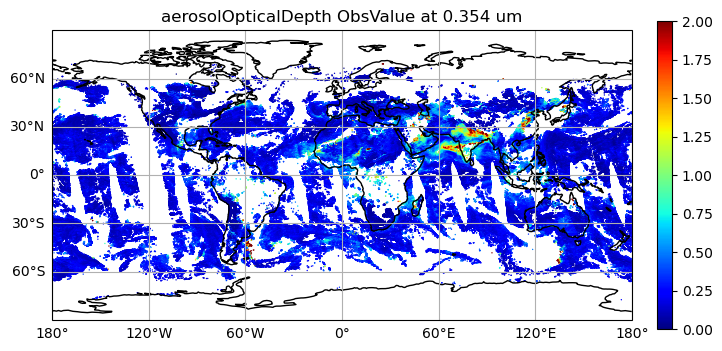

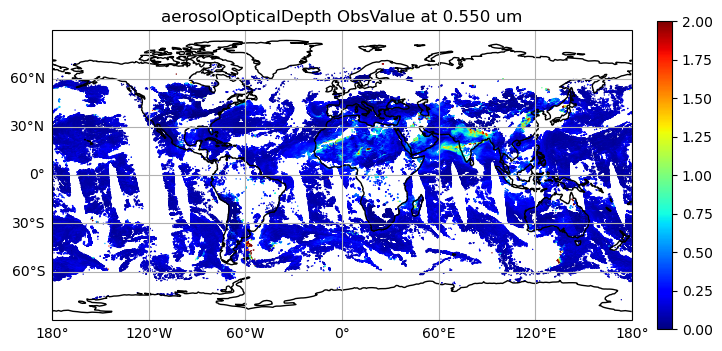

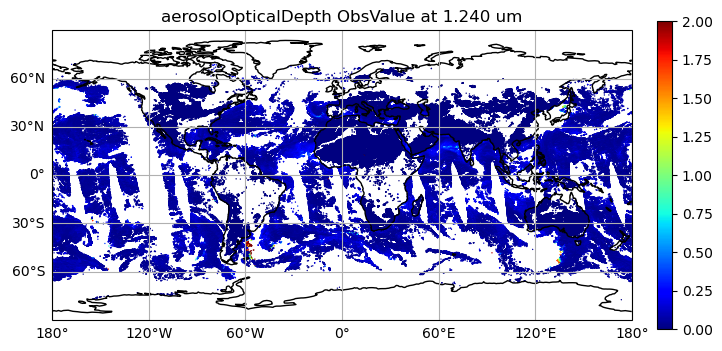

In [15]:
plotgrp = 'ObsValue'
plotvar = 'aerosolOpticalDepth'
plotch_list = [0, 3, 6]
for chidx in plotch_list:
    plot_col = f'{plotgrp}_{plotvar}_{chidx}'
    titlestr = f'{plotvar} {plotgrp} at {channel_meta['sensorCentralWavelength'][chidx]:.3f} um'

    fig, ax, gl = setupax_2dmap(None, gl_lbsize=10)
    sc = plt.scatter(
        multi_df['longitude'],
        multi_df['latitude'],
        c=multi_df[plot_col],
        s=1,
        cmap='jet',
        vmin=0.,
        vmax=2.,
        edgecolors="None",
    )
    ax.set_title(titlestr)
    plt.colorbar(sc, fraction=0.025, pad=0.04, aspect=20)